# Illustrator agent

Given raw text our autonomous agent will:

- Read the article and analyze its topic and structure.
- Decide how many images suit better to the article. Focusing on improving attractiveness while not harming readability.
- Decide where in the article new companion images should be located.
- Create detailed image descriptions suitable to create suggested images using an external image generator model.

In [2]:
import os
import json

from crewai import LLM, Agent, Task, Crew, Process
from dotenv import load_dotenv

from IPython.display import Image

# Configure LLMs and providers

In [2]:
SELECTED_MODEL="deepseek/deepseek-v4-flash-0731"
URL_PROVIDER="https://openrouter.ai/api/v1/chat/completions"
DESIRED_REASONING_EFFORT="high"

# https://api-docs.deepseek.com/guides/thinking_mode/

In [3]:
load_dotenv(override=True)

True

In [4]:
API_KEY = os.getenv("API_KEY")

In [5]:
def get_llm():
    return LLM(model=SELECTED_MODEL, 
               api_key=API_KEY, 
               base_url=URL_PROVIDER,
               reasoning_effort=DESIRED_REASONING_EFFORT,
               )

In [6]:
llm = get_llm()

# General structure of a Crew AI agent

1. Agents
2. Tasks
3. Crew

## 1. Agents

In [7]:
image_creator_agent = Agent(
    role="Senior image creator",
    goal="To generate high-quality image descriptions that align with the content of articles.",
    backstory="You have been analyzing articles for years and know how to create compelling images that capture the essence of the content and increase reader engagement. "
                "You are skilled in understanding the nuances of different topics and can generate image descriptions that are both relevant and engaging.",
    tools=[],
    verbose=True,
    llm=llm
    )

## 2. Tasks

In [8]:
image_creator_task = Task(
    name="Image description generation",
    description="You will generate good quality image descriptions for an article. "
                "Depending on the topic and the length of the article you will decide the number of images. Always between 1 and 3. "
                "This is the article content: {article_content}",
    expected_output="""A list containing JSON objects, each one with 3 keys: 
                    'order' which contains an integer that indicates the order (1,2 ..) of the generated image. 
                    'previous_text': last 4 or 5 words where you decide to insert the image below, just for position reference. 
                    'description': a very detailed image description that can be used to create the image.""",
    context=[],
    agent=image_creator_agent
)

## 3. Crew

In [9]:
crew = Crew(agents=[image_creator_agent],
            tasks=[image_creator_task],
            process=Process.sequential,
            verbose=True)

Configure the crew, i.e. complete variables

In [10]:
# URL: https://www.xataka.com/medicina-y-salud/cantidad-cafeina-bebidas-que-consumimos-a-diario-expuesta-este-grafico

article_content = \
"""
La cantidad de cafeína de las bebidas que consumimos a diario, expuesta en este gráfico
Alejandro Alcolea
5-6 minutos

La cafeína es una de las sustancias más consumidas en el mundo. Se estima que cerca del 80% de la población mundial consume cafeína a diario y, aunque el café es una importante fuente, también está presente en el té, el café, la yerba mate, las vainas de cacao o en la nuez de kola -ingrediente de la Coca-Cola original-. Sin embargo, también se puede producir de forma sintética para añadirla a refrescos, bebidas energéticas o suplementos.

Y en este gráfico elaborado por Visual Capitalist, podemos ver cuánta cafeína tienen las bebidas que consumimos constantemente.

Cafeína de bebidas

El gráfico. Elaborado con datos de EFSA (la Autoridad Europea de Seguridad Alimentaria, en castellano) tras encuestar a más de 66.500 personas de 22 países europeos, el gráfico es bastante autoexplicativo. En algunas publicaciones de este tipo se suele obviar la marca, pero lo realmente útil de este gráfico es que, directamente, se indica la cantidad de cafeína en bebidas comerciales como Monster, Red Bull o Prime (una marca creada por el polémico Logan Paul).

También es útil que se ofrecen tanto los miligramos de cafeína de las bebidas como la cantidad de líquido que consumimos, ya que así podemos calcular de forma más efectiva “cuántos Red Bull puedo tomar para tener una dosis segura”. Un Monster es lo que más cafeína tiene, pero también porque la muestra es de medio litro. Prime, con menos cantidad (330 ml), está cerca de la cafeína de un Monster con sus 140 mg. Y es curioso que la bebida que nos da alas tenga en un bote la misma cantidad que un espresso doble: 80 mg.

No me gusta el café, pero tras repasar lo que dice la ciencia he empezado a consumirlo diariamente

No sólo cafeína. Lo que ocurre con las bebidas energéticas es que, como la propia EFSA detalla, el estimulante que contienen no se limita a la cafeína. Aparte de ese compuesto, tienen otros ingredientes como la taurina o el D-gucorono-y-lactona. La taurina es un aminoácido que participa en el control del calcio celular y la función cardíaca, asociado con la mejora de la resistencia deportiva al permitir mantener altos esfuerzos durante más tiempo, reduciendo la fatiga.

El D-glucurono-y-lactona es un metabolito del glucurónico que ayuda en la síntesis de la vitamina C, y ambos son seguros por su rápida metabolización, pese a que pueden tener efectos segundarios como algunas molestias digestivas en consumos altos. Y si la cafeína, la taurina y el D-glucurono-γ-lactona fueran poco, al cóctel hay que añadir algo más perjudicial: enormes cantidades de azúcar en estas bebidas energéticas.

Consumo por edades. La EFSA ha creado una tabla que indica cuántos mg de cafeína consumimos a diario dependiendo de nuestra edad:

rango de edad
	

Consumo diario

A partir de 75 años
	

22-417 mg

Entre 65 y 75 años
	

23-362 mg

entre 18 y 65 años
	

37-319 mg

entre 10 y 18 años
	

0,4-1,4 mg/kg

entre 3 y 10 años
	

0,2-2,0 mg/kg

entre 12 y 36 meses
	

0-2,1 mg/kg

Entre los adultos, el café es la fuente más importante de cafeína, representando entre el 40% y el 94% de la ingesta total diaria. En Irlanda y Reino Unido, la cosa cambia, y esa fuente principal es el té, representando entre el 59% y el 57% de la ingesta, respectivamente. Entre los adolescentes, la principal fuente de cafeína es el chocolate (tanto en barra como en bebidas de cacao), seguido del café, las bebidas de cola y el té. Y de 10 años para abajo, el café desaparece y el chocolate sigue reinando, seguido del té y de las bebidas de cola.

Hubo un tiempo en que la Coca-Cola tenía 'cocaína'. Que ya no la tenga se debe a algo sorprendente: el racismo

Consumo seguro, pero con asteriscos. Una de las cuestiones que sigue preocupando a quien busca cuidarse es cuánta cafeína es mucha cafeína. Los 400 mg al día se han tomado como la medida universal para decir que es la cantidad “segura”, pero es algo que depende de varios factores. Por ejemplo, dosis únicas de cafeína de hasta 200 mg no presentan problemas de seguridad para la población adulta sana general.

Pero si eres una mujer y estás embarazada, esa cifra segura baja hasta los 200 mg al día, repartidos a lo largo de la jornada. Además, si se consumen dosis únicas de 100 mg antes de irnos a dormir, se puede alterar el patrón de calidad de sueño, pero es algo que no ocurre en todos los adultos.

Pero claro, todo depende de un término clave: población sana, ya que hay estudios que relacionan la cafeína con efectos negativos en fases de restricción crónica del sueño y, si bien se utiliza como estimulante en la práctica deportiva, sus efectos serán más o menos beneficiosos dependiendo del deporte que practiquemos o las decisiones que debamos tomar.
"""

In [11]:
crew_config = {"article_content": article_content}

## Launch execution

In [12]:
result = crew.kickoff(crew_config)

╭──────────────────────────────────────────── Crew Execution Started ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 001c2760-44af-4751-b09a-c6c5996f2e38                                                                       │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior image creator                                                                                    │
│                                                                                                                 │
│  Task: You will generate good quality image descriptions for an article. Depending on the topic and the length  │
│  of the article you will decide the number of images. Always between 1 and 3. This is the article content:      │
│  La cantidad de cafeína de las bebidas que consumimos a diario, expuesta en este gráfico                        │
│  Alejandro Alcolea                                                                                              │
│  5-6 minutos                                                                                                    │
│                                                                                                                 │
│  La cafeína es una de las sustancias más consumidas en el mundo. Se estima que cerca del 80% de la población    │
│  mundial consume cafeína a diario y, aunque el café es una importante fuente, también está presente en el té,   │
│  el café, la yerba mate, las vainas de cacao o en la nuez de kola -ingrediente de la Coca-Cola original-. Sin   │
│  embargo, también se puede producir de forma sintética para añadirla a refrescos, bebidas energéticas o         │
│  suplementos.                                                                                                   │
│                                                                                                                 │
│  Y en este gráfico elaborado por Visual Capitalist, podemos ver cuánta cafeína tienen las bebidas que           │
│  consumimos constantemente.                                                                                     │
│                                                                                                                 │
│  Cafeína de bebidas                                                                                             │
│                                                                                                                 │
│  El gráfico. Elaborado con datos de EFSA (la Autoridad Europea de Seguridad Alimentaria, en castellano) tras    │
│  encuestar a más de 66.500 personas de 22 países europeos, el gráfico es bastante autoexplicativo. En algunas   │
│  publicaciones de este tipo se suele obviar la marca, pero lo realmente útil de este gráfico es que,            │
│  directamente, se indica la cantidad de cafeína en bebidas comerciales como Monster, Red Bull o Prime (una      │
│  marca creada por el polémico Logan Paul).                                                                      │
│                                                                                                                 │
│  También es útil que se ofrecen tanto los miligramos de cafeína de las bebidas como la cantidad de líquido que  │
│  consumimos, ya que así podemos calcular de forma más efectiva “cuántos Red Bull puedo tomar para tener una     │
│  dosis segura”. Un Monster es lo que más cafeína tiene, pero también porque la muestra es de medio litro.       │
│  Prime, con menos cantidad (330 ml), está cerca de la cafeína de un Monster con sus 140 mg. Y es curioso que    │
│  la bebida que nos da alas tenga en un bote la misma cantidad que un espresso doble: 80 mg.                     │
│                                                                                                                 │
│  No me gusta el café, pero tras repasar lo que dice la ciencia he empezado a consumirlo diariamente             │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior image creator                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  [                                                                                                              │
│    {                                                                                                            │
│      "order": 1,                                                                                                │
│      "previous_text": "tienen las bebidas que consumimos constantemente",                                       │
│      "description": "Infografía editorial de estilo Visual Capitalist, con fondo blanco roto y acentos en       │
│  naranja y marrón. En la parte superior aparece el título 'Cafeína en bebidas comunes'. Debajo, se muestran     │
│  varias bebidas cotidianas representadas con ilustración vectorial limpa y realista: una lata grande de bebida  │
│  energética de medio litro, una lata más pequeña de otra marca conocida, una botella de bebida deportiva, un    │
│  vaso de café espresso doble, una taza de café filtrado, una taza de té y una lata de refresco de cola. Cada    │
│  bebida lleva una etiqueta con sus miligramos de cafeína y su cantidad de líquido en mililitros, y al lado se   │
│  dibuja una barra horizontal proporcional con varios colores para comparar visualmente el contenido de          │
│  cafeína. Las bebidas están ordenadas de mayor a menor cafeína total. La composición es limpia, apta para       │
│  artículo de divulgación, con tipografía sans-serif moderna, sombras suaves y un estilo visual atractivo que    │
│  invita a comparar los datos de un vistazo."                                                                    │
│    },                                                                                                           │
│    {                                                                                                            │
│      "order": 2,                                                                                                │
│      "previous_text": "dependiendo de nuestra edad",                                                            │
│      "description": "Tabla de datos sobre consumo diario de cafeína por edades, con estilo de informe           │
│  divulgativo de salud. El fondo es blanco con tonos azul pálido y elementos gráficos suaves. En el centro se    │
│  ve una tabla organizada en dos columnas: en la izquierda, los rangos de edad (a partir de 75 años, entre 65 y  │
│  75 años, entre 18 y 65 años, entre 10 y 18 años, entre 3 y 10 años, entre 12 y 36 meses); en la derecha, las   │
│  cifras de consumo diario en miligramos o miligramos por kilo. Junto a cada fila se incluyen iconos pequeños    │
│  de café, té, chocolate, bebidas de cola y bebidas energéticas para representar las fuentes príncipales según   │
│  la edad. Los colores dominantes son naranja, verde y azul. El título superior dice 'Consumo de cafeína por     │
│  edades según EFSA'. La composición es horizontal, clara y muy legible, pensada para ilustrar un artículo de    │
│  divulgación científica sobre cafeína."                                                                         │
│    },                                                                                                           │
│    {                                                                                                            │
│      "order": 3,                                       

╭──────────────────────────────────────────────── Task Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Image description generation                                                                             │
│  Agent: Senior image creator                                                                                    │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 001c2760-44af-4751-b09a-c6c5996f2e38                                                                       │
│  Tool Args:                                                                                                     │
│  Final Output: [                                                                                                │
│    {                                                                                                            │
│      "order": 1,                                                                                                │
│      "previous_text": "tienen las bebidas que consumimos constantemente",                                       │
│      "description": "Infografía editorial de estilo Visual Capitalist, con fondo blanco roto y acentos en       │
│  naranja y marrón. En la parte superior aparece el título 'Cafeína en bebidas comunes'. Debajo, se muestran     │
│  varias bebidas cotidianas representadas con ilustración vectorial limpa y realista: una lata grande de bebida  │
│  energética de medio litro, una lata más pequeña de otra marca conocida, una botella de bebida deportiva, un    │
│  vaso de café espresso doble, una taza de café filtrado, una taza de té y una lata de refresco de cola. Cada    │
│  bebida lleva una etiqueta con sus miligramos de cafeína y su cantidad de líquido en mililitros, y al lado se   │
│  dibuja una barra horizontal proporcional con varios colores para comparar visualmente el contenido de          │
│  cafeína. Las bebidas están ordenadas de mayor a menor cafeína total. La composición es limpia, apta para       │
│  artículo de divulgación, con tipografía sans-serif moderna, sombras suaves y un estilo visual atractivo que    │
│  invita a comparar los datos de un vistazo."                                                                    │
│    },                                                                                                           │
│    {                                                                                                            │
│      "order": 2,                                                                                                │
│      "previous_text": "dependiendo de nuestra edad",                                                            │
│      "description": "Tabla de datos sobre consumo diario de cafeína por edades, con estilo de informe           │
│  divulgativo de salud. El fondo es blanco con tonos azul pálido y elementos gráficos suaves. En el centro se    │
│  ve una tabla organizada en dos columnas: en la izquierda, los rangos de edad (a partir de 75 años, entre 65 y  │
│  75 años, entre 18 y 65 años, entre 10 y 18 años, entre 3 y 10 años, entre 12 y 36 meses); en la derecha, las   │
│  cifras de consumo diario en miligramos o miligramos por kilo. Junto a cada fila se incluyen iconos pequeños    │
│  de café, té, chocolate, bebidas de cola y bebidas energéticas para representar las fuentes príncipales según   │
│  la edad. Los colores dominantes son naranja, verde y azul. El título superior dice 'Consumo de cafeína por     │
│  edades según EFSA'. La composición es horizontal, clara y muy legible, pensada para ilustrar un artículo de    │
│  divulgación científica sobre cafeína."                                                                         │
│    },                                                                                                           │
│    {                                                  

## Results

In [13]:
print(result.raw)

[
  {
    "order": 1,
    "previous_text": "tienen las bebidas que consumimos constantemente",
    "description": "Infografía editorial de estilo Visual Capitalist, con fondo blanco roto y acentos en naranja y marrón. En la parte superior aparece el título 'Cafeína en bebidas comunes'. Debajo, se muestran varias bebidas cotidianas representadas con ilustración vectorial limpa y realista: una lata grande de bebida energética de medio litro, una lata más pequeña de otra marca conocida, una botella de bebida deportiva, un vaso de café espresso doble, una taza de café filtrado, una taza de té y una lata de refresco de cola. Cada bebida lleva una etiqueta con sus miligramos de cafeína y su cantidad de líquido en mililitros, y al lado se dibuja una barra horizontal proporcional con varios colores para comparar visualmente el contenido de cafeína. Las bebidas están ordenadas de mayor a menor cafeína total. La composición es limpia, apta para artículo de divulgación, con tipografía sans-serif 

## Costs

In [14]:
crew.usage_metrics

UsageMetrics(total_tokens=5622, prompt_tokens=1684, cached_prompt_tokens=0, completion_tokens=3938, successful_requests=1)

# Let's visualize the results

https://aistudio.google.com

Model: Nano Banana

In [15]:
result_json = json.loads(result.raw)

## Image 1

In [16]:
print(result_json[0]['description'])

Infografía editorial de estilo Visual Capitalist, con fondo blanco roto y acentos en naranja y marrón. En la parte superior aparece el título 'Cafeína en bebidas comunes'. Debajo, se muestran varias bebidas cotidianas representadas con ilustración vectorial limpa y realista: una lata grande de bebida energética de medio litro, una lata más pequeña de otra marca conocida, una botella de bebida deportiva, un vaso de café espresso doble, una taza de café filtrado, una taza de té y una lata de refresco de cola. Cada bebida lleva una etiqueta con sus miligramos de cafeína y su cantidad de líquido en mililitros, y al lado se dibuja una barra horizontal proporcional con varios colores para comparar visualmente el contenido de cafeína. Las bebidas están ordenadas de mayor a menor cafeína total. La composición es limpia, apta para artículo de divulgación, con tipografía sans-serif moderna, sombras suaves y un estilo visual atractivo que invita a comparar los datos de un vistazo.


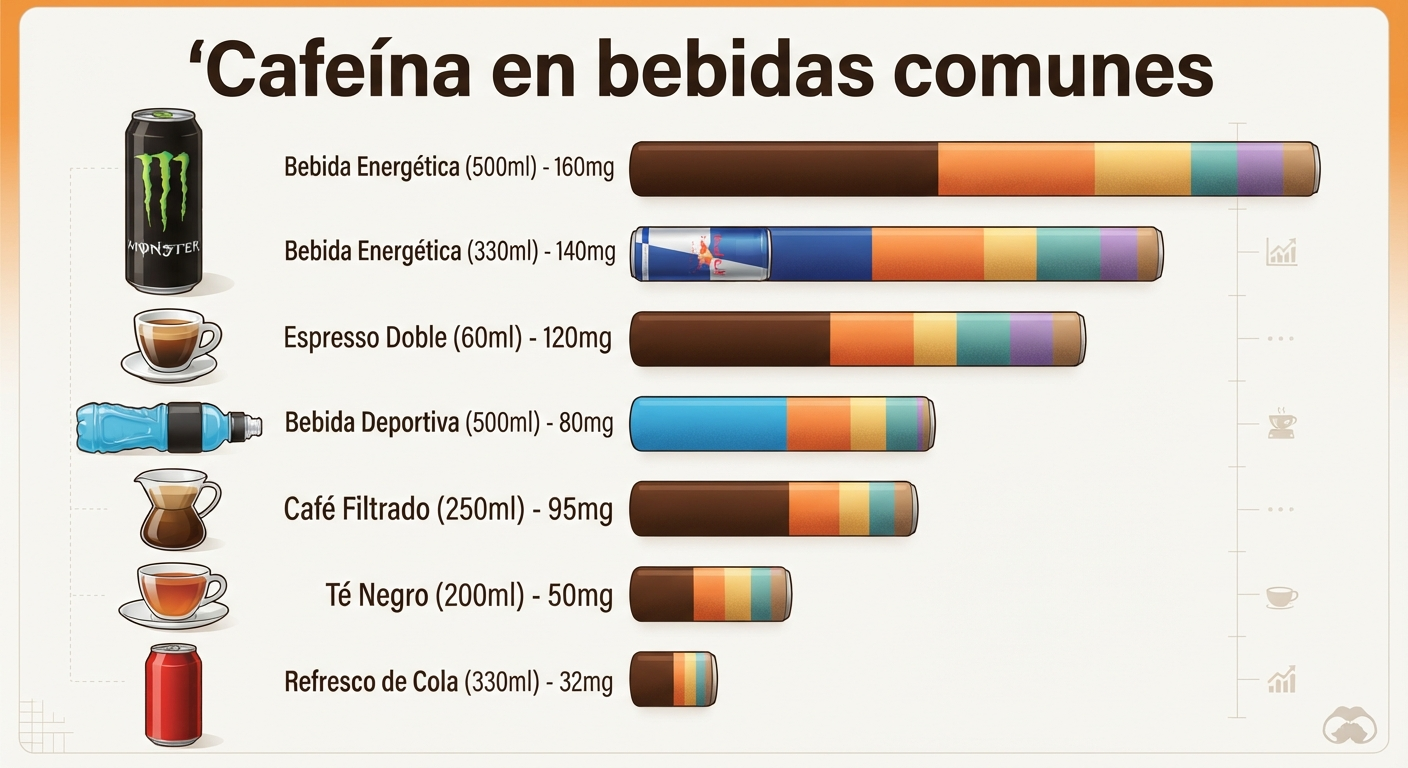

In [4]:
Image(filename="../../resources/reasoning_generated1.jpg", retina=True)

## Image 2

In [18]:
print(result_json[1]['description'])

Tabla de datos sobre consumo diario de cafeína por edades, con estilo de informe divulgativo de salud. El fondo es blanco con tonos azul pálido y elementos gráficos suaves. En el centro se ve una tabla organizada en dos columnas: en la izquierda, los rangos de edad (a partir de 75 años, entre 65 y 75 años, entre 18 y 65 años, entre 10 y 18 años, entre 3 y 10 años, entre 12 y 36 meses); en la derecha, las cifras de consumo diario en miligramos o miligramos por kilo. Junto a cada fila se incluyen iconos pequeños de café, té, chocolate, bebidas de cola y bebidas energéticas para representar las fuentes príncipales según la edad. Los colores dominantes son naranja, verde y azul. El título superior dice 'Consumo de cafeína por edades según EFSA'. La composición es horizontal, clara y muy legible, pensada para ilustrar un artículo de divulgación científica sobre cafeína.


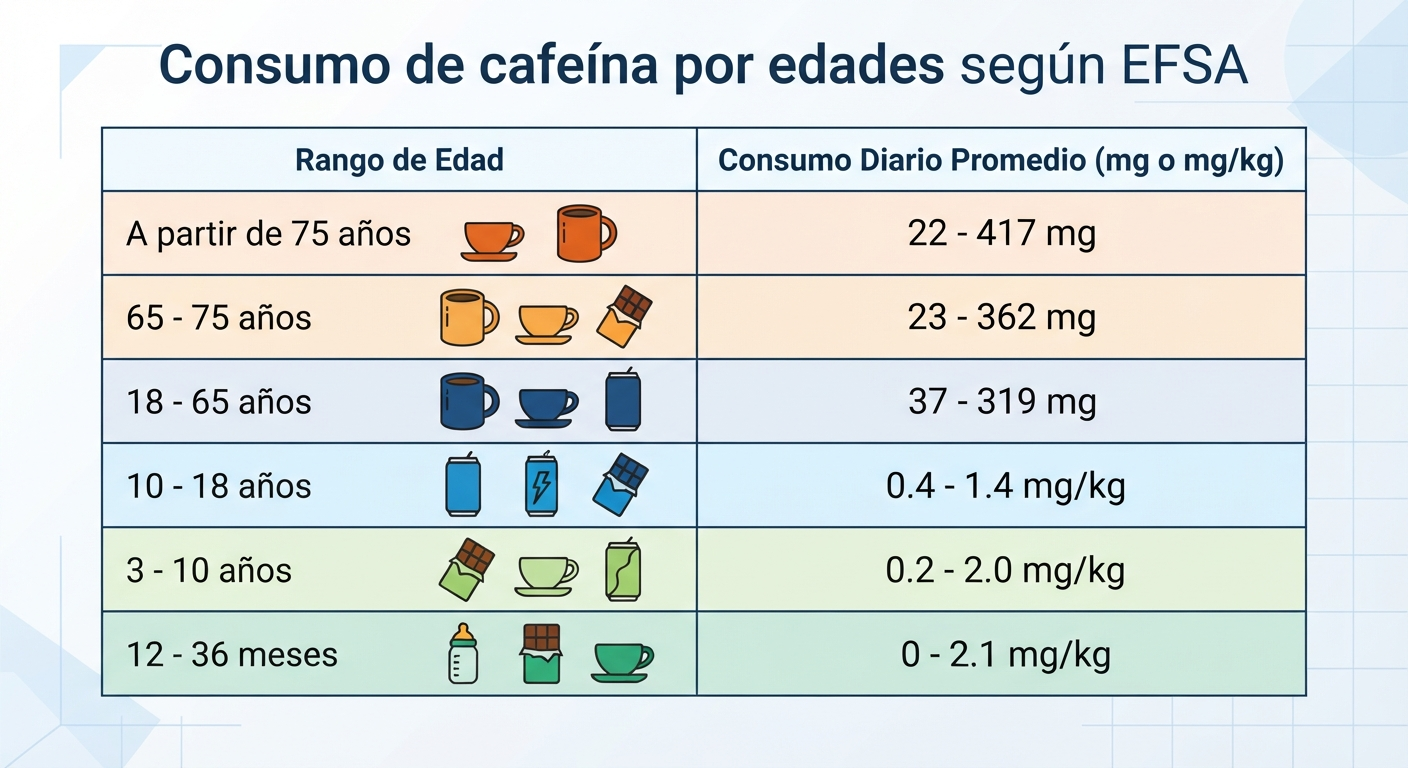

In [6]:
Image(filename="../../resources/reasoning_generated2.jpg", retina=True)

## Image 3

In [20]:
print(result_json[2]['description'])

Ilustración conceptual sobre la seguridad del consumo de cafeína, con estilo editorial de divulgación científica. El fondo es crema suave y aparecen elementos semirealistas: una taza de café humeante, una lata de bebida energética, una taza de té y una onza de chocolate. En el centro se destaca un gran diagrama circular tipo diana con las cifras clave: '400 mg al día' marcada como cantidad segura para población adulta sana, '200 mg al día' con el símbolo de embarazo, y '100 mg antes de dormir' con una luna creciente. Alrededor se dibujan pequeños iconos de corazón, pulso cardíaco y reloj para representar la salud y los factores individuales. La paleta es cálida con naranja, ámbar, azul oscuro y blanco. La composición es equilbrada, con espacio negatvo, tipografía moderna y un tono cercano pero riguroso, ideal para acompañar la explicación sobre los límites de cafeína y sus asteriscos.


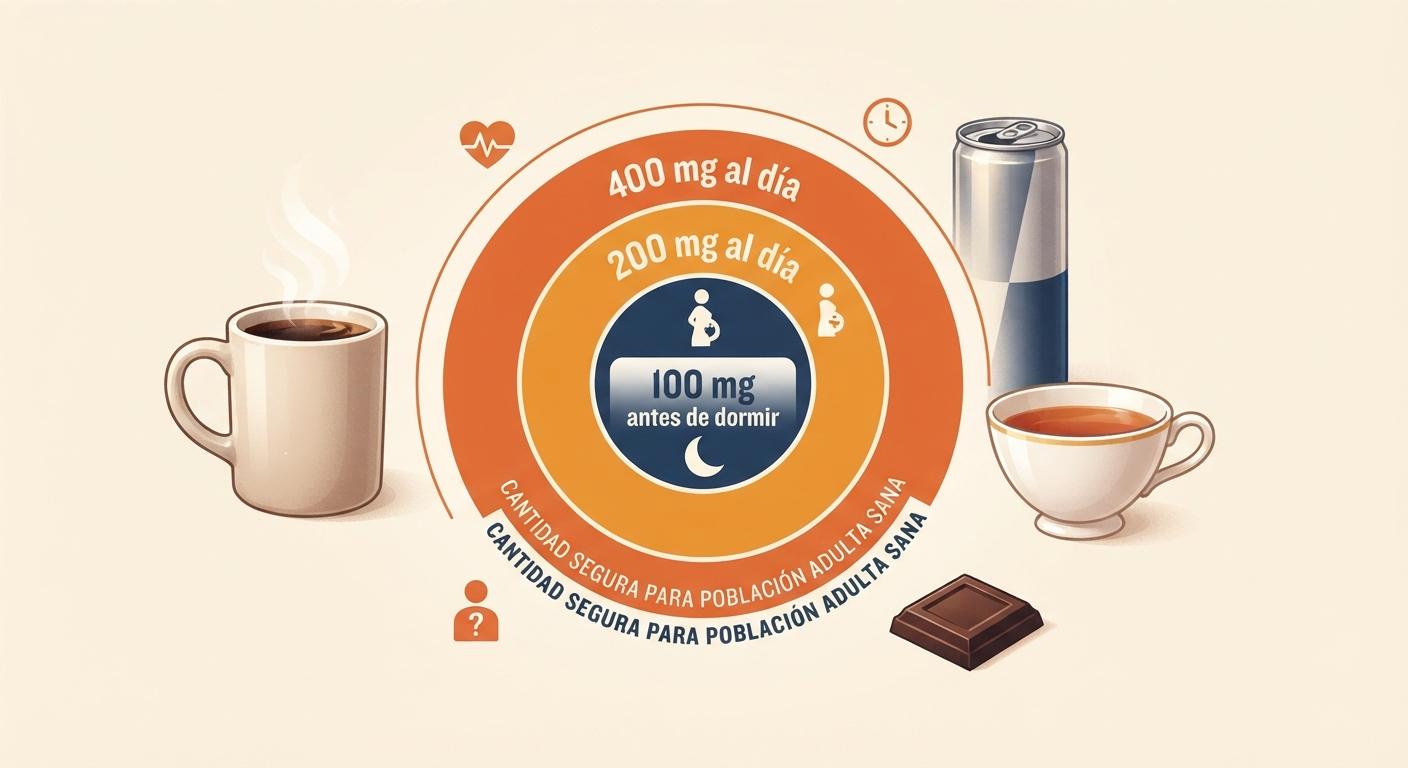

In [7]:
Image(filename="../../resources/reasoning_generated3.jpg", retina=True)

# Improvements

- Images:
  - Less charts, less scientific, more companion, illustration. 
  - Tailored to the audience (topic, age, country) and the device (mobile, computer).
  
- Why manual interconnection?
  - Monitor a shared folder. Thus when our community manager writes the article and send it to us in Dropbox we can trigger the agent's crew to automatically read the content and start the processing.
  - Use generated image descriptions to call an API to create the image and retrieve it from code.
  - Instead of manually inserting the image, generate the final document with images inserted in the correct place


Key takeaways

- **Integration is the key my friend!!**
- Robustness in production is extremely important.
  - LLM may hallucinate (or troll you as I prefer to say)
  - 3º party services can behave in different ways as you expect (read documentation cough cough): image models may block specific brands or celebrities